# EDA: Discovery Results for Data Snapshot Metadata Schema

This notebook analyzes `discovery_results.csv` as an evidence-gathering step toward a unified Data Snapshot Metadata Schema. It intentionally stops short of declaring the final schema.

## Setup

Load the discovery results and define helper functions for reproducible summaries.

In [1]:
import pyperclip


def df_to_clipboard(df, index=False):
    pyperclip.copy(df.to_markdown(index=index))

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

CSV_PATH = Path("discovery_results.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("notebooks/schema_discovery/discovery_results.csv")
SNAPSHOT_ROOT = Path("/home/ajd/hf_datasets/data-snapshot/snapshots")


def source_set(series: pd.Series) -> str:
    """Join unique corpus/source labels for display.

    Parameters
    ----------
    series : pandas.Series
        Source labels.

    Returns
    -------
    str
        Comma-separated sorted source labels.
    """
    return ", ".join(sorted(series.dropna().astype(str).unique()))


def source_level_set(series: pd.Series) -> str:
    """Join unique source-level labels for display.

    Parameters
    ----------
    series : pandas.Series
        Source-level labels.

    Returns
    -------
    str
        Comma-separated sorted source-level labels.
    """
    return ", ".join(sorted(series.dropna().astype(str).unique()))


def normalize_field_name(name: str) -> str:
    """Normalize field names for exploratory alias grouping.

    Parameters
    ----------
    name : str
        Metadata field name.

    Returns
    -------
    str
        Lightly normalized field name for grouping likely aliases.
    """
    normalized = name.lower().strip()
    replacements = {
        "figure_": "",
        "table_": "",
        "chart_": "",
        "snapshot_": "",
        "x_axis_": "",
        "y_axis_": "",
        "axis_": "",
        "_names": "_name",
        "_labels": "_label",
        "_values": "_value",
        "_categories": "_category",
        "_dimensions": "_dimension",
        "_variables": "_variable",
        "_measures": "_measure",
        "_topics": "_topic",
        "_domains": "_domain",
    }
    for old, new in replacements.items():
        normalized = normalized.replace(old, new)
    return normalized


def assign_family(field: str) -> str:
    """Assign a metadata field to a broad exploratory schema family.

    Parameters
    ----------
    field : str
        Metadata field name.

    Returns
    -------
    str
        Broad metadata family label.
    """
    patterns = [
        ("title_subject_topic", r"title|caption|subject|topic|theme|domain"),
        ("indicator_measure", r"indicator|metric|measure|variable|outcome|dependent|explanatory|statistic"),
        ("geography", r"geo|country|region|location|administrative|spatial|province|district|area"),
        ("time", r"time|date|year|period|temporal|frequency"),
        ("unit_scale_currency", r"unit|currency|scale|percent|rate|denominator"),
        ("dimensions_categories", r"dimension|category|label|series|row|column|axis|group|panel"),
        ("population_entities", r"population|beneficiar|household|gender|age|refugee|entity"),
        ("provenance_source", r"source|citation|organization|agency|publisher|author|provenance|dataset"),
        ("method_analysis", r"method|analysis|model|regression|estimat|sample|significance"),
        ("project_finance", r"project|component|sector|financ|budget|cost|expenditure|funding"),
    ]
    for family, pattern in patterns:
        if re.search(pattern, field):
            return family
    return "other"


df = pd.read_csv(CSV_PATH)
df.head()

,snapshot_id,snapshot_type,source,model,metadata_field,observed_value,description,source_level,discovery_value,reasoning
0,027_Jordan-Emergency-Food-Security-Project_figure_001.png,figure,refugee,gpt-5.5,figure_title,Figure 2: Share of food expenditure in total expenditure p.c. (%),The title or caption identifying the figure and its subject.,snapshot,high,The figure title provides the most direct searchable description of the snapshot content.
1,027_Jordan-Emergency-Food-Security-Project_figure_001.png,figure,refugee,gpt-5.5,indicator_name,Share of food expenditure in total expenditure p.c.,The main measure or indicator represented in the figure.,snapshot,high,Indicator-level metadata enables retrieval of figures by the specific economic or food-security measure shown.
2,027_Jordan-Emergency-Food-Security-Project_figure_001.png,figure,refugee,gpt-5.5,subject_domain,Food expenditure; food security,The thematic domain or topical area represented by the snapshot.,both,high,The figure title and document metadata both connect the snapshot to food expenditure and food security topics.
3,027_Jordan-Emergency-Food-Security-Project_figure_001.png,figure,refugee,gpt-5.5,geographic_scope,"Jordan, inferred from parent document title and project name; not visible in snapshot","The country, region, or geographic area to which the figure data applies.",document,high,Geographic context is essential for discovery because it is not shown in the figure itself.
4,027_Jordan-Emergency-Food-Security-Project_figure_001.png,figure,refugee,gpt-5.5,time_period,Not identifiable from this snapshot,"The date, year, or period covered by the data in the figure.",snapshot,high,"A data time period would be highly useful for comparison, but it is not visible in the figure."


## 1. Data Audit and Sample Balance

The sample is balanced by snapshot type and corpus, making figure/table and corpus comparisons meaningful. This section also flags missing values and duplicate snapshot-field pairs.

In [3]:
required_columns = [
    "snapshot_id",
    "snapshot_type",
    "source",
    "model",
    "metadata_field",
    "observed_value",
    "description",
    "source_level",
    "discovery_value",
    "reasoning",
]

basic_summary = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "columns", "value": df.shape[1]},
    {"metric": "unique_snapshots", "value": df["snapshot_id"].nunique()},
    {"metric": "unique_metadata_fields", "value": df["metadata_field"].nunique()},
    {"metric": "unique_sources", "value": df["source"].nunique()},
    {"metric": "unique_models", "value": df["model"].nunique()},
])

snapshot_balance = df.groupby(["source", "snapshot_type"])["snapshot_id"].nunique().unstack(fill_value=0)
row_balance = pd.crosstab(df["source"], df["snapshot_type"])
rows_per_snapshot = (
    df.groupby(["snapshot_type", "snapshot_id"])
    .size()
    .groupby("snapshot_type")
    .describe()
    .round(2)
)
missing_counts = df[required_columns].isna().sum().rename("missing_count").reset_index(name="column")
missing_rows = df[df[required_columns].isna().any(axis=1)]
duplicate_pairs = (
    df.groupby(["snapshot_id", "metadata_field"])
    .size()
    .reset_index(name="n")
    .query("n > 1")
)

print("Basic summary")
display(basic_summary)
print("Unique snapshots by corpus/source and snapshot type")
display(snapshot_balance)
print("Rows by corpus/source and snapshot type")
display(row_balance)
print("Rows per snapshot by type")
display(rows_per_snapshot)
print("Missing counts")
display(missing_counts)
print("Rows with missing values")
display(missing_rows)
print("Duplicate snapshot_id + metadata_field pairs")
display(duplicate_pairs)

Basic summary


,metric,value
0,rows,3041
1,columns,10
2,unique_snapshots,210
3,unique_metadata_fields,833
4,unique_sources,3
5,unique_models,1


Unique snapshots by corpus/source and snapshot type


snapshot_type,figure,table
source,,
prwp,35,35
refugee,35,35
unhcr,35,35


Rows by corpus/source and snapshot type


...

,index,column
0,snapshot_id,0
1,snapshot_type,0
2,source,0
3,model,0
4,metadata_field,0
5,observed_value,1
6,description,0
7,source_level,0
8,discovery_value,0
9,reasoning,0


Rows with missing values


,snapshot_id,snapshot_type,source,model,metadata_field,observed_value,description,source_level,discovery_value,reasoning
2891,document_717473_table_019.png,table,prwp,gpt-5.5,missing_value_marker,NaN,Symbol or text used to indicate unavailable or not applicable data values.,snapshot,medium,Recording missing-value notation supports correct interpretation and reuse of tabular data.


Duplicate snapshot_id + metadata_field pairs


,snapshot_id,metadata_field,n


## 2. Field Frequency and Long-Tail Behavior

The field-name space is highly long-tailed. This is the strongest reason to treat the EDA as schema consolidation evidence rather than a direct field list.

Distinct metadata fields: 833
Singleton fields: 581 (69.7% of distinct fields)
Top 10 row share: 40.1%


,field_frequency_bucket,n_fields
0,1,581
1,2,107
2,3-5,80
3,6-10,32
4,11-20,16
5,21-50,5
6,51-100,7
7,101+,5


,metadata_field,rows,snapshots,figure_snapshots,table_snapshots,n_corpus_present,corpora_present,source_levels,high,medium,low
318,geographic_scope,192,192,96,96,3,"prwp, refugee, unhcr","both, document, snapshot",135,55,2
792,unit_of_measure,180,180,98,82,3,"prwp, refugee, unhcr",snapshot,160,20,0
354,indicator_name,152,152,89,63,3,"prwp, refugee, unhcr",snapshot,152,0,0
767,time_period,149,149,86,63,3,"prwp, refugee, unhcr","both, document, snapshot",129,20,0
596,row_dimension,102,102,16,86,3,"prwp, refugee, unhcr",snapshot,85,17,0
815,visualization_type,99,99,96,3,3,"prwp, refugee, unhcr",snapshot,13,86,0
738,table_title,90,90,1,89,3,"prwp, refugee, unhcr",snapshot,80,9,1
98,column_dimension,88,88,14,74,3,"prwp, refugee, unhcr",snapshot,70,18,0
269,figure_title,84,84,81,3,3,"prwp, refugee, unhcr",snapshot,83,1,0
518,population_group,84,84,41,43,3,"prwp, refugee, unhcr","both, document, snapshot",69,15,0


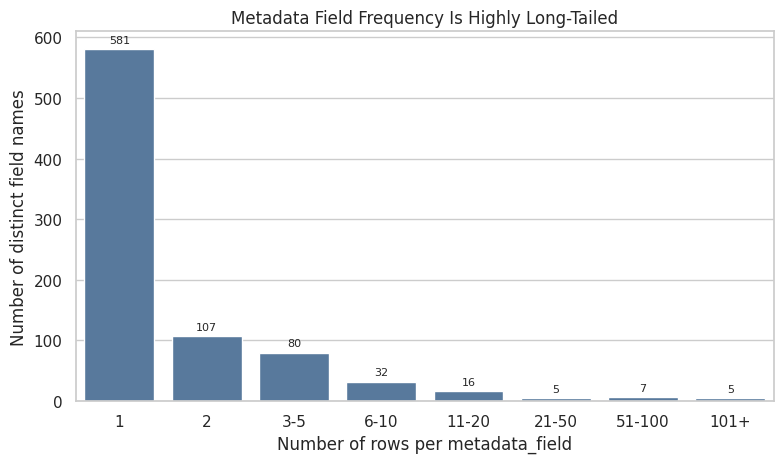

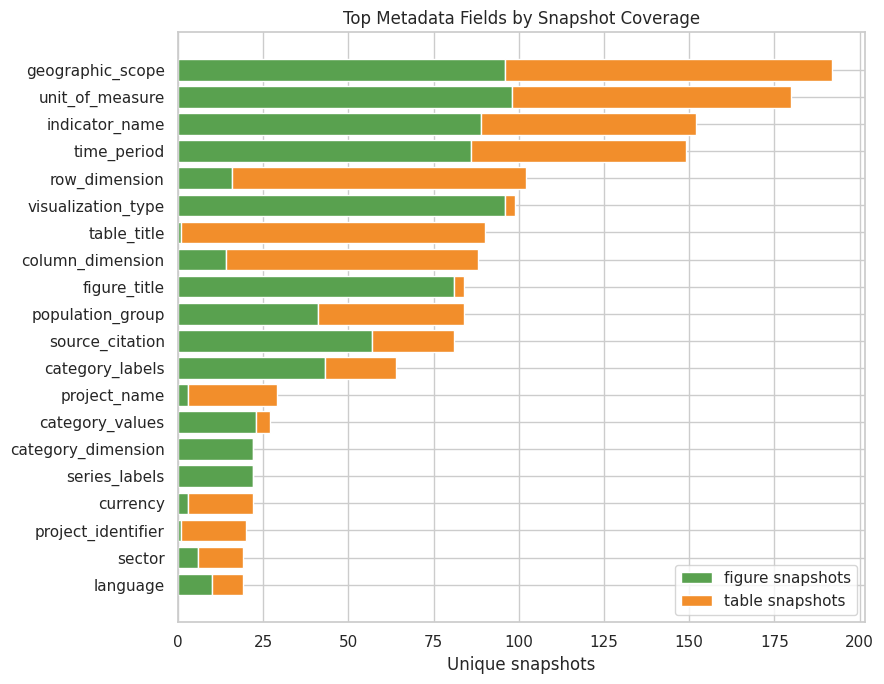

In [4]:
field_counts = df["metadata_field"].value_counts()
field_frequency_buckets = (
    pd.cut(
        field_counts,
        bins=[0, 1, 2, 5, 10, 20, 50, 100, 10_000],
        labels=["1", "2", "3-5", "6-10", "11-20", "21-50", "51-100", "101+"],
    )
    .value_counts()
    .sort_index()
    .rename_axis("field_frequency_bucket")
    .reset_index(name="n_fields")
)

field_stats = (
    df.groupby("metadata_field")
    .agg(
        rows=("metadata_field", "size"),
        snapshots=("snapshot_id", "nunique"),
        figure_snapshots=("snapshot_id", lambda s: df.loc[s.index][df.loc[s.index, "snapshot_type"].eq("figure")]["snapshot_id"].nunique()),
        table_snapshots=("snapshot_id", lambda s: df.loc[s.index][df.loc[s.index, "snapshot_type"].eq("table")]["snapshot_id"].nunique()),
        n_corpus_present=("source", "nunique"),
        corpora_present=("source", source_set),
        source_levels=("source_level", source_level_set),
        high=("discovery_value", lambda s: int((s == "high").sum())),
        medium=("discovery_value", lambda s: int((s == "medium").sum())),
        low=("discovery_value", lambda s: int((s == "low").sum())),
    )
    .reset_index()
    .sort_values(["snapshots", "rows"], ascending=False)
)

top_field_stats = field_stats.head(40)

print(f"Distinct metadata fields: {df['metadata_field'].nunique()}")
print(f"Singleton fields: {(field_counts == 1).sum()} ({(field_counts == 1).mean() * 100:.1f}% of distinct fields)")
print(f"Top 10 row share: {field_counts.head(10).sum() / len(df) * 100:.1f}%")
display(field_frequency_buckets)
display(top_field_stats.head(30))

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=field_frequency_buckets, x="field_frequency_bucket", y="n_fields", color="#4C78A8", ax=ax)
ax.set_title("Metadata Field Frequency Is Highly Long-Tailed")
ax.set_xlabel("Number of rows per metadata_field")
ax.set_ylabel("Number of distinct field names")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=8)
plt.tight_layout()
plt.show()

plot_top = top_field_stats.head(20).sort_values("snapshots")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_top["metadata_field"], plot_top["figure_snapshots"], label="figure snapshots", color="#59A14F")
ax.barh(plot_top["metadata_field"], plot_top["table_snapshots"], left=plot_top["figure_snapshots"], label="table snapshots", color="#F28E2B")
ax.set_title("Top Metadata Fields by Snapshot Coverage")
ax.set_xlabel("Unique snapshots")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [5]:
df_to_clipboard(field_frequency_buckets)

## 3. Figure/Table Overlap and Strong Type-Specific Fields

Most schema candidates should be evaluated by whether they work across both figures and tables, but strong type-specific fields may still be important extension points.

Strong figure-only fields (>=5 figure snapshots, 0 table snapshots)


snapshot_type,metadata_field,figure,table,total_snapshots
77,category_dimension,22,0,22
627,series_labels,22,0,22
817,x_axis_dimension,13,0,13
625,series_dimension,11,0,11
822,x_axis_variable,11,0,11
832,y_axis_variable,10,0,10
267,figure_number,8,0,8
649,snapshot_title,8,0,8
827,y_axis_measure,8,0,8
88,chart_title,7,0,7


Strong table-only fields (>=5 table snapshots, 0 figure snapshots)


snapshot_type,metadata_field,figure,table,total_snapshots
737,table_subject,0,15,15
730,table_number,0,7,7
197,dependent_variables,0,6,6
58,baseline_value,0,6,6
20,aggregation_level,0,6,6
642,significance_notation,0,6,6
791,unit_of_analysis,0,6,6
287,financing_source,0,6,6
490,outcome_variable,0,6,6
258,explanatory_variables,0,5,5


Strong cross-type fields


snapshot_type,metadata_field,figure,table,total_snapshots
318,geographic_scope,96,96,192
792,unit_of_measure,98,82,180
354,indicator_name,89,63,152
767,time_period,86,63,149
596,row_dimension,16,86,102
815,visualization_type,96,3,99
738,table_title,1,89,90
98,column_dimension,14,74,88
518,population_group,41,43,84
269,figure_title,81,3,84


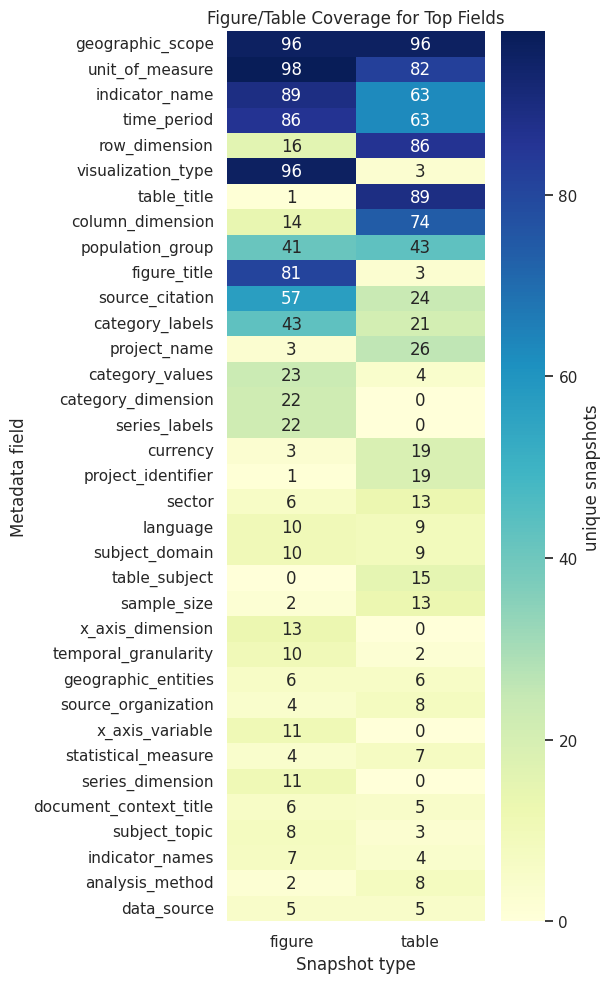

In [6]:
field_type_coverage = (
    df.groupby(["metadata_field", "snapshot_type"])["snapshot_id"]
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["figure", "table"]:
    if col not in field_type_coverage.columns:
        field_type_coverage[col] = 0
field_type_coverage["total_snapshots"] = field_type_coverage["figure"] + field_type_coverage["table"]

figure_only_fields = field_type_coverage.query("figure >= 5 and table == 0").sort_values("figure", ascending=False)
table_only_fields = field_type_coverage.query("table >= 5 and figure == 0").sort_values("table", ascending=False)
strong_cross_type_fields = field_type_coverage.query("figure > 0 and table > 0").sort_values("total_snapshots", ascending=False)

print("Strong figure-only fields (>=5 figure snapshots, 0 table snapshots)")
display(figure_only_fields.head(25))
print("Strong table-only fields (>=5 table snapshots, 0 figure snapshots)")
display(table_only_fields.head(25))
print("Strong cross-type fields")
display(strong_cross_type_fields.head(30))

heat = field_type_coverage.sort_values("total_snapshots", ascending=False).head(35).set_index("metadata_field")[["figure", "table"]]
fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(heat, annot=True, fmt="d", cmap="YlGnBu", ax=ax, cbar_kws={"label": "unique snapshots"})
ax.set_title("Figure/Table Coverage for Top Fields")
ax.set_xlabel("Snapshot type")
ax.set_ylabel("Metadata field")
plt.tight_layout()
plt.show()

In [7]:
df_to_clipboard(figure_only_fields.head(25))

In [8]:
df_to_clipboard(table_only_fields.head(25))

In [9]:
df_to_clipboard(strong_cross_type_fields.head(30))

## 4. Corpus-Specific and Cross-Corpus Fields

Corpus-specific fields may reflect real institutional document genres. This section flags them for review rather than treating them as errors.

Repeated corpus-specific fields (one corpus only, >=5 snapshots)


source,metadata_field,prwp,refugee,unhcr,total_snapshots,n_corpus_present
543,project_name,0,29,0,29,1
542,project_identifier,0,20,0,20,1
822,x_axis_variable,11,0,0,11,1
832,y_axis_variable,10,0,0,10,1
581,research_topic,9,0,0,9,1
39,analytical_method,8,0,0,8,1
197,dependent_variables,6,0,0,6,1
222,document_type,0,6,0,6,1
287,financing_source,0,6,0,6,1
490,outcome_variable,6,0,0,6,1


Fields present in all three corpora


source,metadata_field,prwp,refugee,unhcr,total_snapshots,n_corpus_present
318,geographic_scope,67,69,56,192,3
792,unit_of_measure,50,62,68,180,3
354,indicator_name,42,45,65,152,3
767,time_period,48,47,54,149,3
596,row_dimension,26,44,32,102,3
815,visualization_type,33,31,35,99,3
738,table_title,35,28,27,90,3
98,column_dimension,25,41,22,88,3
269,figure_title,34,19,31,84,3
518,population_group,25,24,35,84,3


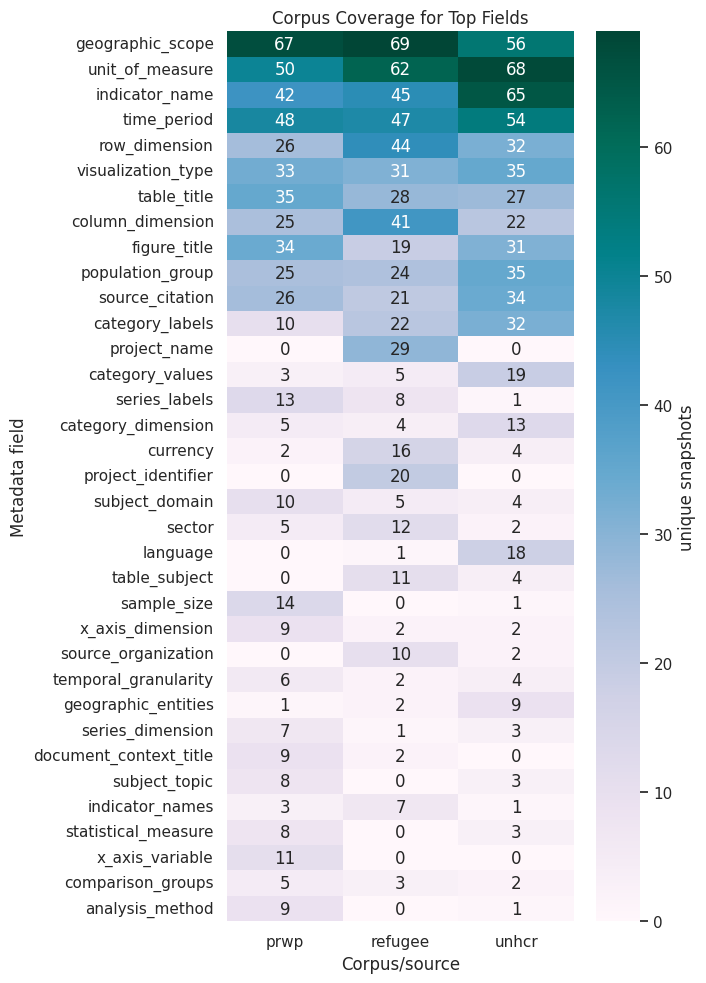

In [10]:
field_source_coverage = (
    df.groupby(["metadata_field", "source"])["snapshot_id"]
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["prwp", "refugee", "unhcr"]:
    if col not in field_source_coverage.columns:
        field_source_coverage[col] = 0
field_source_coverage["total_snapshots"] = field_source_coverage[["prwp", "refugee", "unhcr"]].sum(axis=1)
field_source_coverage["n_corpus_present"] = (field_source_coverage[["prwp", "refugee", "unhcr"]] > 0).sum(axis=1)
field_source_coverage = field_source_coverage.sort_values(["n_corpus_present", "total_snapshots"], ascending=False)

corpus_specific_fields = field_source_coverage.query("n_corpus_present == 1 and total_snapshots >= 5").sort_values("total_snapshots", ascending=False)
all_corpus_fields = field_source_coverage.query("n_corpus_present == 3").sort_values("total_snapshots", ascending=False)

print("Repeated corpus-specific fields (one corpus only, >=5 snapshots)")
display(corpus_specific_fields.head(40))
print("Fields present in all three corpora")
display(all_corpus_fields.head(40))

corpus_heat = field_source_coverage.sort_values("total_snapshots", ascending=False).head(35).set_index("metadata_field")[["prwp", "refugee", "unhcr"]]
fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(corpus_heat, annot=True, fmt="d", cmap="PuBuGn", ax=ax, cbar_kws={"label": "unique snapshots"})
ax.set_title("Corpus Coverage for Top Fields")
ax.set_xlabel("Corpus/source")
ax.set_ylabel("Metadata field")
plt.tight_layout()
plt.show()

In [11]:
df_to_clipboard(corpus_specific_fields.head(40))

In [12]:
df_to_clipboard(all_corpus_fields.head(40))

## 5. Source-Level Analysis

This section examines whether field values come from the snapshot, document metadata, or both. It includes the requested field x source_level x snapshot_type x n_corpus_present matrix.

Source level x snapshot type x discovery value


discovery_value,source_level,snapshot_type,high,low,medium
0,both,figure,79,0,22
1,both,table,78,0,19
2,document,figure,17,6,50
3,document,table,25,6,99
4,snapshot,figure,938,3,394
5,snapshot,table,989,5,311


Field x source_level x snapshot_type x n_corpus_present matrix (fields with >=10 snapshots)


,metadata_field,source_level,snapshot_type,n_snapshots,n_corpus_present,corpora_present,snapshots
367,geographic_scope,both,figure,40,2,"prwp, refugee",192
368,geographic_scope,both,table,31,2,"prwp, refugee",192
369,geographic_scope,document,figure,22,2,"prwp, refugee",192
370,geographic_scope,document,table,34,2,"prwp, refugee",192
371,geographic_scope,snapshot,figure,34,3,"prwp, refugee, unhcr",192
...,...,...,...,...,...,...,...
209,data_source,snapshot,figure,5,2,"refugee, unhcr",10
210,data_source,snapshot,table,2,1,prwp,10
225,data_values,snapshot,figure,7,3,"prwp, refugee, unhcr",10
226,data_values,snapshot,table,3,2,"refugee, unhcr",10


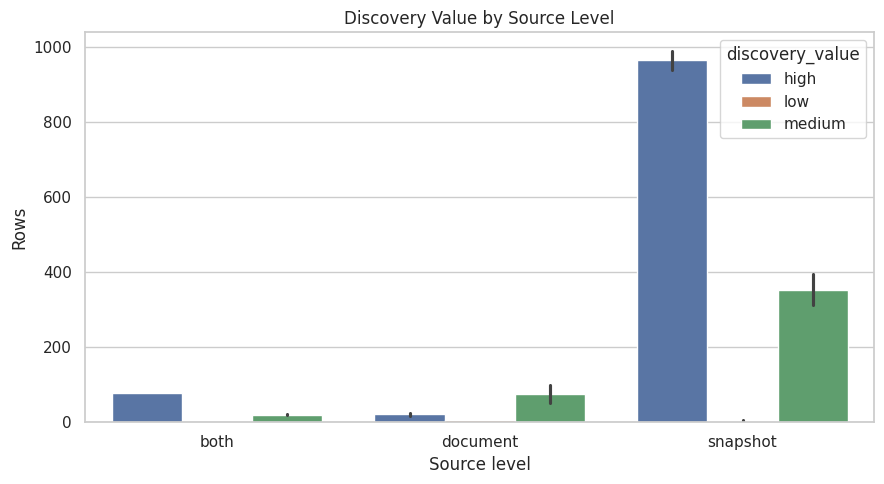

In [13]:
source_level_summary = pd.crosstab([df["source_level"], df["snapshot_type"]], df["discovery_value"]).reset_index()
source_level_long = source_level_summary.melt(id_vars=["source_level", "snapshot_type"], var_name="discovery_value", value_name="rows")

field_source_level_matrix = (
    df.groupby(["metadata_field", "source_level", "snapshot_type"])
    .agg(
        n_snapshots=("snapshot_id", "nunique"),
        n_corpus_present=("source", "nunique"),
        corpora_present=("source", source_set),
    )
    .reset_index()
    .merge(field_stats[["metadata_field", "snapshots"]], on="metadata_field", how="left")
    .query("snapshots >= 10")
    .sort_values(["snapshots", "metadata_field", "source_level", "snapshot_type"], ascending=[False, True, True, True])
)

print("Source level x snapshot type x discovery value")
display(source_level_summary)
print("Field x source_level x snapshot_type x n_corpus_present matrix (fields with >=10 snapshots)")
display(field_source_level_matrix.head(100))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=source_level_long, x="source_level", y="rows", hue="discovery_value", ax=ax)
ax.set_title("Discovery Value by Source Level")
ax.set_xlabel("Source level")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

In [14]:
df_to_clipboard(source_level_summary)

In [15]:
df_to_clipboard(field_source_level_matrix.head(100))

## 6. Geographic Scope Provenance

`geographic_scope` has very high support. The key question is whether it is visible in the snapshot or inherited from document metadata.

geographic_scope rows: 192
source_level
both        71
snapshot    65
document    56
By snapshot type, corpus, and source_level


source_level           both  document  snapshot
snapshot_type source                           
figure        prwp       11        17         6
              refugee    29         5         1
              unhcr       0         0        27
table         prwp       19        12         2
              refugee    12        22         0
              unhcr       0         0        29

By source_level and discovery_value


discovery_value,high,low,medium
source_level,,,
both,67,0,4
document,22,1,33
snapshot,46,1,18


Examples


,snapshot_id,snapshot_type,source,source_level,observed_value
21,054_Sudan-Basic-Education-Emergency-Support-Project_figure_001.png,figure,refugee,both,Sudan; Jordan; Iraq; Morocco; Egypt; Yemen
31,134_PAD7340ARABIC00n0220020140Arabic01_figure_000.png,figure,refugee,both,الأردن / Jordan
45,004_BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112_figure_000.png,figure,refugee,both,Djibouti
58,202_multi0page_figure_000.png,figure,refugee,both,Uganda
74,200_multi-page_table_004.png,table,refugee,both,"Croatia; Eastern Slavonia, Baranja and Western Srijem"
89,200_multi-page_table_003.png,table,refugee,both,Croatia; Eastern Slavonia; Baranja; Western Srijem; Vinkovci
120,195_multi-page_table_012.png,table,refugee,both,Jordan
135,120_PAD1205-ARABIC-PAD-PP152646-PUBLIC-Box393206B_table_008.png,table,refugee,both,"Lebanon; regions/governorates listed include North Lebanon, Bekaa, Mount Lebanon, South Lebanon, Nabatieh, and Beirut"
3,027_Jordan-Emergency-Food-Security-Project_figure_001.png,figure,refugee,document,"Jordan, inferred from parent document title and project name; not visible in snapshot"
308,134_PAD7340ARABIC00n0220020140Arabic01_figure_001.png,figure,refugee,document,Jordan


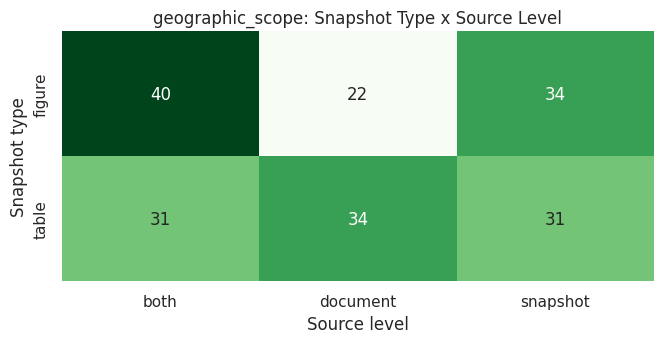

In [16]:
geo = df[df["metadata_field"].eq("geographic_scope")].copy()
geo_source_level = pd.crosstab([geo["snapshot_type"], geo["source"]], geo["source_level"])
geo_discovery = pd.crosstab(geo["source_level"], geo["discovery_value"])
geo_examples = (
    geo.groupby(["source_level", "snapshot_type"])
    .head(4)[["snapshot_id", "snapshot_type", "source", "source_level", "observed_value"]]
    .sort_values(["source_level", "snapshot_type", "source"])
)

print(f"geographic_scope rows: {len(geo)}")
print(geo["source_level"].value_counts().to_string())
print("By snapshot type, corpus, and source_level")
display(geo_source_level)
print("By source_level and discovery_value")
display(geo_discovery)
print("Examples")
display(geo_examples.head(24))

geo_heat = pd.crosstab(geo["snapshot_type"], geo["source_level"])
fig, ax = plt.subplots(figsize=(6.8, 3.6))
sns.heatmap(geo_heat, annot=True, fmt="d", cmap="Greens", ax=ax, cbar=False)
ax.set_title("geographic_scope: Snapshot Type x Source Level")
ax.set_xlabel("Source level")
ax.set_ylabel("Snapshot type")
plt.tight_layout()
plt.show()

In [17]:
df_to_clipboard(geo_source_level, index=True)

In [18]:
df_to_clipboard(geo_discovery, index=True)

## 7. Field Families and Alias Candidates

This is exploratory canonicalization evidence. The goal is to identify likely consolidation work, not to finalize names.

In [19]:
family_df = df.copy()
family_df["field_family"] = family_df["metadata_field"].map(assign_family)
family_summary = (
    family_df.groupby("field_family")
    .agg(
        rows=("metadata_field", "size"),
        unique_fields=("metadata_field", "nunique"),
        snapshots=("snapshot_id", "nunique"),
        figure_snapshots=("snapshot_id", lambda s: family_df.loc[s.index][family_df.loc[s.index, "snapshot_type"].eq("figure")]["snapshot_id"].nunique()),
        table_snapshots=("snapshot_id", lambda s: family_df.loc[s.index][family_df.loc[s.index, "snapshot_type"].eq("table")]["snapshot_id"].nunique()),
        n_corpus_present=("source", "nunique"),
    )
    .reset_index()
    .sort_values(["snapshots", "rows"], ascending=False)
)

alias_df = field_stats.copy()
alias_df["alias_key"] = alias_df["metadata_field"].map(normalize_field_name)
alias_candidates = (
    alias_df.groupby("alias_key")
    .agg(
        n_field_names=("metadata_field", "nunique"),
        field_names=("metadata_field", lambda s: ", ".join(sorted(s.unique())[:12])),
        total_snapshots=("snapshots", "sum"),
        max_single_field_snapshots=("snapshots", "max"),
        n_corpus_present=("n_corpus_present", "max"),
    )
    .reset_index()
    .query("n_field_names > 1")
    .sort_values(["total_snapshots", "n_field_names"], ascending=False)
)

print("Exploratory field families")
display(family_summary)
print("Likely alias groups from light normalization")
display(alias_candidates.head(50))

Exploratory field families


,field_family,rows,unique_fields,snapshots,figure_snapshots,table_snapshots,n_corpus_present
9,title_subject_topic,354,60,207,104,103,3
2,indicator_measure,607,149,205,101,104,3
1,geography,305,64,201,103,98,3
4,other,493,259,197,105,92,3
0,dimensions_categories,592,102,195,95,100,3
8,time,226,41,170,95,75,3
7,provenance_source,149,33,126,71,55,3
6,project_finance,117,38,58,18,40,3
3,method_analysis,90,33,51,14,37,3
10,unit_scale_currency,56,24,49,21,28,3


Likely alias groups from light normalization


,alias_key,n_field_names,field_names,total_snapshots,max_single_field_snapshots,n_corpus_present
746,title,4,"chart_title, figure_title, snapshot_title, table_title",189,90,3
768,unit_of_measure,3,"unit_of_measure, x_axis_unit_of_measure, y_axis_unit_of_measure",182,180,3
342,indicator_name,3,"chart_indicator_names, indicator_name, indicator_names",164,152,3
92,column_dimension,2,"column_dimension, column_dimensions",90,88,3
620,series_label,3,"chart_series_labels, series_label, series_labels",25,22,3
779,variable,2,"x_axis_variable, y_axis_variable",21,11,1
371,language,2,"language, snapshot_language",20,19,2
696,subject_domain,2,"subject_domain, subject_domains",20,19,3
775,value_range,5,"axis_value_range, value_axis_range, value_range, x_axis_value_range, y_axis_value_range",16,6,2
456,number,2,"figure_number, table_number",15,8,3


In [20]:
df_to_clipboard(family_summary)

In [21]:
df_to_clipboard(alias_candidates)

## 8. Validation Checks

These assertions lock the observed source-data shape and catch accidental CSV changes. The missing-value check reflects the EDA finding that one `observed_value` cell is blank.

In [22]:
assert len(df) == 3041
assert df.shape[1] == 10
assert df["snapshot_id"].nunique() == 210
assert df[df["snapshot_type"].eq("figure")]["snapshot_id"].nunique() == 105
assert df[df["snapshot_type"].eq("table")]["snapshot_id"].nunique() == 105
assert (df.groupby(["source", "snapshot_type"])["snapshot_id"].nunique() == 35).all()
assert duplicate_pairs.empty
assert df["metadata_field"].nunique() == 833
assert int((field_counts == 1).sum()) == 581
for expected in ["geographic_scope", "unit_of_measure", "indicator_name", "time_period"]:
    assert expected in field_counts.head(10).index

# The EDA found one real missing value, not zero: observed_value is empty for missing_value_marker.
assert int(df[required_columns].isna().sum().sum()) == 1
assert missing_rows.iloc[0]["metadata_field"] == "missing_value_marker"
assert pd.isna(missing_rows.iloc[0]["observed_value"])

print("All validation checks passed. Note: one missing observed_value is intentionally retained as a data-quality finding.")

All validation checks passed. Note: one missing observed_value is intentionally retained as a data-quality finding.


## 9. Schema Implications

- **A unified snapshot title field is strongly supported, but naming is split.** `figure_title` and `table_title` are both frequent; a future `snapshot_title` or equivalent should be considered.
- **Core cross-type fields are stable.** `geographic_scope`, `unit_of_measure`, `indicator_name`, and `time_period` all appear across figures and tables with high support.
- **Dimension modeling needs care.** Tables concentrate `row_dimension` and `column_dimension`; figures add `category_dimension`, `series_dimension`, and axis fields. The EDA supports a generalized dimension concept, but the final schema should decide whether to preserve role-specific fields or use structured dimension objects.
- **Figure-only and table-only fields are real signals.** The notebook surfaces fields with repeated support in only one snapshot type so they can be considered as extensions rather than discarded as noise.
- **Corpus specificity should be reviewed before pruning.** Repeated one-corpus fields may reflect document genre rather than prompt artifacts.
- **`geographic_scope` is not purely document-derived.** The notebook separates snapshot, document, and both source levels so this high-support field can be modeled with provenance.

### Open design questions

- Should figure/table title fields collapse to `snapshot_title`, or should type-specific aliases be retained for compatibility?
- Should dimensions be represented as separate scalar fields or as structured dimension objects?
- Which corpus-specific fields are reusable across institutional documents, and which are local to the sampled corpora?
- Should source provenance be split into `source_citation`, `data_source`, and `source_organization`, or represented as a provenance object?